CSV files used in this notebook to load animal shelter data
1. Yearly shelter data (2021 - 2025) CSV file kentucky_shelter_data.csv 
   - Stored in data/
   - Downloaded from the Louisville Metro site https://data.louisvilleky.gov

2. Yearly shelter data (2017 - 2025) CSV file BloomingtonIN_Animal_Shelter_Animals.csv 
   - Stored in data/ 
   - Downloaded from the City of Bloomington site https://data.bloomington.in.gov

3. Yearly shelter data (2013-2025) CSV files Austin_Animal_Center_Intakes.csv &Austin_Animal_Center_Outcomes 
   - Stored in data/ 
   - Downloaded from the City of Austin open data portal site https://data.austintexas.gov

   Note: Data was filtered due to size, for analysis, to the range of 1.1.23 - 7.31.25

Functions included in this notebook
1. convert_date_columns : converts date fields to a datetime in order to do calculations
2. add_length_of_stay : calculates the length of stay in the shelter for each intake
3. filter_by_date_range : trims the dataframes to the specified time period to reduce # of rows
4. load_dataframe_to_tables : loads the SQL Lite tables one at a time using the defined dictionary
5. categorize_intake_reason : adds a standardized intake category column for reporting
6. categorize_outcome : adds a standardized outcome category column for reporting

Notes:
The function add_length_of_stay was a bit difficult due to the result being a timedelta
- Pandas Timedelta internally uses nanoseconds.
- If you don’t convert .dt.days to an integer type, Pandas may still treat it as a timedelta-like object.
- SQLite doesn’t have a native timedelta type, so it stores the raw representation (nanoseconds).
- Combining the steps did not work and still caused the dType to be timedelta.
- I had to break each piece into seperate steps in order order to get this work.  
- ChatGPT, CoPilot and I spent several hours trying different combinations until we got one to work.

The functions categorize_intake_reason and categorize_outcome
- These were added after the inital SQL Lite table load and a SELECT DISTINCT on the intakeReason and outcome was done
- I used AI to help map the categories to save time

SQL Lite
Database Name: animalshelterdata.db
Tables Created: Animal, Shelter, Intake, Outcome
ERD can be found in the additional documents folder

SQL queries included in this notebook
1. most common intake reason by species 
2. most common outcome for an animal by species
3. average length of stay for each species by shelter
4. average length of stay by species for the outcomes: Adoption, Return to Owner and Euthanized
5. average yearly adoption rates by species for each shelter
6. average yearly euthanization rates by species for each shelter

Notes:
1.  most common intake reason by species
- Google, StackOverflow and AI was consulted because SQL Lite doesn't allow MAX(COUNT(*)) directly in a subquery

Visualizations included 

1. Intake Total and Category Total by Year: Stacked Bar Chart
2. Heatmap of Species Outcomes:  Heatmap
3. Positive vs Negative Outcome Types Ratio: Pie Chart
4. Average Days in Shelter by Species: Bar Chart
5. Adoptions by Day of the Week: Bar Chart

In [7]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
import sqlite3

In [ ]:
# FOR TESTING PURPOSES ONLY !!!!!!
# this will delete the dataframes so you can run the program multiple times 
# del df, df2, df3


Functions used in Data Cleaning

In [1]:
# This function converts date fields to a datetime in order to do calculations
# Must be run after columns are renamed

def convert_date_columns(df, intake_col="intakeDate", outcome_col="outcomeDate"):

    df["indate"] = pd.to_datetime(df[intake_col], errors="coerce")
    df["outdate"] = pd.to_datetime(df[outcome_col], errors="coerce")
    
    return df

In [2]:
# This function calculates the length of stay in the shelter for each intake
# Must be run after columns are renamed and the convert_date_columns function.

def add_length_of_stay(df):
    
    # Make sure the dates are datetime
    df["indate"] = pd.to_datetime(df["indate"], errors="coerce")
    df["outdate"] = pd.to_datetime(df["outdate"], errors="coerce")

    # Calculate timedelta
    df["lengthOfStay"] = df["outdate"] - df["indate"]

    # Convert timedelta to integer days
    df["lengthOfStay"] = df["lengthOfStay"].dt.days

    # Fill missing values with 0 and convert to Int64 (SQLite compatible)
    df["lengthOfStay"] = df["lengthOfStay"].fillna(0).astype("Int64")
    
    return df

In [3]:
# This function trims the dataframes to the time period of 01-01-2017 thru 07-31-2025
# Must be run after columns are renamed and the convert_date_columns function

def filter_by_date_range(df, start_date="2023-01-01", end_date="2025-07-31"):
    df["indate"] = pd.to_datetime(df["indate"], errors='coerce')
    df["outdate"] = pd.to_datetime(df["outdate"], errors='coerce')
    return df[
        (df["indate"] >= start_date) & (df["indate"] <= end_date) &
        (df["outdate"] >= start_date) & (df["outdate"] <= end_date)
    ]

    return df

In [4]:
# Add Intake Category column to the dataframe in order to group the different reasons into reportable data

def categorize_intake_reason(df, reason_col="intakeReason", new_col="intakeCategory"):

    # Normalize for matching
    normalized = df[reason_col].astype(str).str.strip().str.lower()

    df[new_col] = (
        normalized
        .map({

            # Owner Surrender – Non-Behavior
            "allergies": "Owner Surrender - Non-Behavioral",
            "financial constraints": "Owner Surrender - Non-Behavioral",
            "housing": "Owner Surrender - Non-Behavioral",
            "landlord issues": "Owner Surrender - Non-Behavioral",
            "marriage/relationship split": "Owner Surrender - Non-Behavioral",
            "medical": "Owner Surrender - Non-Behavioral",
            "moving": "Owner Surrender - Non-Behavioral",
            "owner surrender": "Owner Surrender - Non-Behavioral",
            "owner sur": "Owner Surrender - Non-Behavioral",
            "owner deceased": "Owner Surrender - Non-Behavioral",
            "unable to afford": "Owner Surrender - Non-Behavioral",
            "unsuitable accommodation": "Owner Surrender - Non-Behavioral",

            # Behavioral
            "behavior": "Owner Surrender - Behavioral",
            "biting": "Owner Surrender - Behavioral",
            "incompatible with other pets": "Owner Surrender - Behavioral",
            "incompatible with owner lifestyle": "Owner Surrender - Behavioral",
            "return adopt - behavior": "Owner Surrender - Behavioral",
            "return adopt - incompatible with other pets": "Owner Surrender - Behavioral",
            "return adopt - incompatible with owner lifestyle": "Owner Surrender - Behavioral",
            "return adopt - lifestyle issue": "Owner Surrender - Behavioral",

            # Stray / Found
            "found": "Stray",
            "stray": "Stray",
            "tnr - trap/neuter/release": "Stray",
            
           # Wildlife
            "injured wildlife": "Wildlife",
            "wildlife": "Wildlife",

            # Confiscation / Legal
            "confiscate": "Legal Confiscation",
            "impound or seizure": "Legal Confiscation",
            "police assist": "Legal Confiscation",
            "public assist": "Legal Confiscation",
            "rabies monitoring": "Legal Confiscation",

            # Transfer
            "transfer from other shelter": "Transfer",
            "for transp": "Transfer",
            "foster": "Transfer",
            "return": "Transfer",

            # Euthanasia
            "doa": "Euthanasia",
            "disposal": "Euthanasia",
            "euthanasia request": "Euthanasia",
            "owner requested euthanasia": "Euthanasia",

            # Abandoned / Neglect
            "abandoned": "Abandoned Neglect",
            "abuse/ neglect": "Abandoned Neglect",

            # Litter / Offspring
            "born in shelter": "Offspring",
            "litter relinquishment": "Offspring",

        })
        .fillna("Other")
    )

    return df


In [5]:
# Add Outcome Category column to the dataframe in order to group the different outcomes into reportable data

def categorize_outcome(df, outcome_col="outcome", new_col="outcomeCategory"):
   
    # Normalize values for matching
    normalized = df[outcome_col].astype(str).str.strip().str.lower()

    df[new_col] = (
        normalized.map({

            # Adoption
            "adoption": "Adoption",
            "rto-adopt": "Adoption",

            # Return to Owner
            "rto": "Return to Owner",
            "return to owner": "Return to Owner",
            "reclaimed": "Return to Owner",

            # Foster
            "foster": "Foster",

            # Transfer
            "transfer": "Transfer",
            "transport": "Transfer",
            "retailer": "Transfer",

            # Trap-Neuter-Return / community cat programs
            "tnr": "TNR",
            "rtf": "TNR",
            "snr": "TNR",

            # Wild release or relocate
            "released to wild": "Wild Release",
            "release": "Wild Release",
            "relocate": "Wild Release",

            # Found after missing
            "found exp": "Reunited",

            # Died / euthanasia / disposal
            "died": "Died",
            "died ": "Died",
            "euth": "Euthanized",
            "euthanasia": "Euthanized",
            "disposal": "Died",
            "disposal ": "Died",

            # Lost or stolen
            "lost": "Lost",
            "missing": "Lost",
            "stolen": "Stolen",

            # Escape
            "escaped": "Escaped",

            # Unknown
            "unknown": "Unknown"

        }).fillna("Unknown")
    )

    return df


Load dataset from Louisville, KY

In [8]:
# Read in the csv file
# original csv file name was shortened for easier use

data = pd.read_csv('../data/kentucky_shelter_data.csv')

# Make a copy of the data to work with
df = data.copy()

Preview and Analyze the data structure

In [9]:
df.head()

,kennel,animalid,jurisdiction,intype,insubtype,indate,surreason,outtype,outsubtype,outdate,animaltype,sex,bites,petsize,color,breed,sourcezipcode,ObjectId
0,408,A688221,40216,STRAY,OTC,2021-01-17 00:00:00,STRAY,TRANSPORT,RESCUE GRP,2021-02-06 00:00:00,DOG,M,N,PUPPY,BR BRINDLE,CHIHUAHUA SH / MIX,40218,1
1,ID07,A688234,40222,STRAY,OTC,2021-01-18 00:00:00,STRAY,RTO,IN FIELD,2021-01-18 00:00:00,DOG,N,N,MED,BR BRINDLE / WHITE,BOSTON TERRIER / MIX,40205,2
2,DW13,A688337,40118,STRAY,OTC,2021-01-21 00:00:00,STRAY,RTO,IN KENNEL,2021-01-23 00:00:00,DOG,S,N,LARGE,WHITE / BROWN,CATAHOULA / MIX,40118,3
3,INTAKE,A688419,40204,STRAY,OTC,2021-02-03 00:00:00,STRAY,TNR,CARETAKER,2021-02-04 00:00:00,CAT,S,N,MED,BLK TABBY,DOMESTIC SH,40204,4
4,INTAKE,A688478,40214,STRAY,OTC,2021-02-10 00:00:00,STRAY,TNR,CARETAKER,2021-02-11 00:00:00,CAT,N,N,MED,TORTIE,DOMESTIC SH,40210,5


In [10]:
df.tail()

,kennel,animalid,jurisdiction,intype,insubtype,indate,surreason,outtype,outsubtype,outdate,animaltype,sex,bites,petsize,color,breed,sourcezipcode,ObjectId
60338,N03,A743176,40272,STRAY,FIELD,2023-08-11 00:00:00,STRAY,ADOPTION,WALK IN,2023-10-03 00:00:00,DOG,S,N,LARGE,BLACK / BROWN,ROTTWEILER,40272,60339
60339,N31,A743450,40272,STRAY,OTC,2023-08-15 00:00:00,STRAY,ADOPTION,INTERNET,2023-09-18 00:00:00,DOG,N,N,MED,TAN / WHITE,PIT BULL,40272,60340
60340,FOUND,A743593,NaN,FOUND,WEB,2023-08-18 00:00:00,NaN,NaN,NaN,NaN,DOG,F,NaN,MED,BROWN,STAFFORDSHIRE,NaN,60341
60341,808,A743612,40215,STRAY,OTC,2023-08-19 00:00:00,STRAY,RTO,NaN,2023-08-29 00:00:00,DOG,M,N,MED,BR BRINDLE,CANE CORSO,40215,60342
60342,207,A743612,40215,STRAY,OTC,2024-06-28 00:00:00,STRAY,EUTH,BEHAV OBSV,2024-07-03 00:00:00,DOG,M,N,MED,BR BRINDLE,CANE CORSO,40215,60343


In [11]:
df.describe()

,ObjectId
count,60343.000000
mean,30172.000000
std,17419.667984
min,1.000000
25%,15086.500000
50%,30172.000000
75%,45257.500000
max,60343.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60343 entries, 0 to 60342
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   kennel         60343 non-null  object
 1   animalid       60343 non-null  object
 2   jurisdiction   47038 non-null  object
 3   intype         60343 non-null  object
 4   insubtype      60216 non-null  object
 5   indate         60343 non-null  object
 6   surreason      47038 non-null  object
 7   outtype        46755 non-null  object
 8   outsubtype     37967 non-null  object
 9   outdate        46789 non-null  object
 10  animaltype     60343 non-null  object
 11  sex            59318 non-null  object
 12  bites          47053 non-null  object
 13  petsize        57919 non-null  object
 14  color          60342 non-null  object
 15  breed          60267 non-null  object
 16  sourcezipcode  50868 non-null  object
 17  ObjectId       60343 non-null  int64 
dtypes: int64(1), object(17)
me

In [13]:
df.columns

Index(['kennel', 'animalid', 'jurisdiction', 'intype', 'insubtype', 'indate',
       'surreason', 'outtype', 'outsubtype', 'outdate', 'animaltype', 'sex',
       'bites', 'petsize', 'color', 'breed', 'sourcezipcode', 'ObjectId'],
      dtype='object')

In [14]:
df.shape

(60343, 18)

In [15]:
df.dtypes

kennel           object
animalid         object
jurisdiction     object
intype           object
insubtype        object
indate           object
surreason        object
outtype          object
outsubtype       object
outdate          object
animaltype       object
sex              object
bites            object
petsize          object
color            object
breed            object
sourcezipcode    object
ObjectId          int64
dtype: object

Data Clean Up
- Rename Columns
- Add Shelter information
- Drop columns not needed for analysis
- Check for Missing Data
- Count of Missing Data
- Replace necessary missing data
- Call Function to convert date columns to datetime format
- Call Function to trim data set to specific date range
- Check for duplicates
- Drop Duplicate Columns
- Drop Duplicate Rows
- Call Function for Length of Stay

In [16]:
# Rename columns to clearer names for use
df.columns = ["kennelId",
"animalId",
"jurisdiction",
"intakeReason",
"intakeSubtype",
"intakeDate",
"surreason",
"outcome",
"outcomeSubtype",
"outcomeDate",
"species",
"sex",
"bites",
"petsize",
"color",
"breed",
"zipcode",
"objectId"
]

In [17]:
# Convert species to lowercase, strip spaces
df['species'] = df['species'].astype(str).str.strip().str.lower()

df.head()

,kennelId,animalId,jurisdiction,intakeReason,intakeSubtype,intakeDate,surreason,outcome,outcomeSubtype,outcomeDate,species,sex,bites,petsize,color,breed,zipcode,objectId
0,408,A688221,40216,STRAY,OTC,2021-01-17 00:00:00,STRAY,TRANSPORT,RESCUE GRP,2021-02-06 00:00:00,dog,M,N,PUPPY,BR BRINDLE,CHIHUAHUA SH / MIX,40218,1
1,ID07,A688234,40222,STRAY,OTC,2021-01-18 00:00:00,STRAY,RTO,IN FIELD,2021-01-18 00:00:00,dog,N,N,MED,BR BRINDLE / WHITE,BOSTON TERRIER / MIX,40205,2
2,DW13,A688337,40118,STRAY,OTC,2021-01-21 00:00:00,STRAY,RTO,IN KENNEL,2021-01-23 00:00:00,dog,S,N,LARGE,WHITE / BROWN,CATAHOULA / MIX,40118,3
3,INTAKE,A688419,40204,STRAY,OTC,2021-02-03 00:00:00,STRAY,TNR,CARETAKER,2021-02-04 00:00:00,cat,S,N,MED,BLK TABBY,DOMESTIC SH,40204,4
4,INTAKE,A688478,40214,STRAY,OTC,2021-02-10 00:00:00,STRAY,TNR,CARETAKER,2021-02-11 00:00:00,cat,N,N,MED,TORTIE,DOMESTIC SH,40210,5


In [18]:
# Add Shelter Name, Location and Shelter ID Column

df['shelterName'] = 'Louisville Metro Animal Services'
df['shelterID'] = 'KYLMAS01'
df['city'] = 'Louisville'
df['state'] = 'KY'


In [19]:
# Drop columns not needed for analysis
df = df.drop(columns=["kennelId", "jurisdiction", "intakeSubtype", "surreason", "outcomeSubtype", "bites", "petsize", "zipcode", "objectId"])

In [20]:
# Verify column changes
df.columns

Index(['animalId', 'intakeReason', 'intakeDate', 'outcome', 'outcomeDate',
       'species', 'sex', 'color', 'breed', 'shelterName', 'shelterID', 'city',
       'state'],
      dtype='object')

In [21]:
# check for missing data
df.isna()

,animalId,intakeReason,intakeDate,outcome,outcomeDate,species,sex,color,breed,shelterName,shelterID,city,state
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60338,False,False,False,False,False,False,False,False,False,False,False,False,False
60339,False,False,False,False,False,False,False,False,False,False,False,False,False
60340,False,False,False,True,True,False,False,False,False,False,False,False,False
60341,False,False,False,False,False,False,False,False,False,False,False,False,False


In [22]:
# count of missing data
df.isna().sum()

animalId            0
intakeReason        0
intakeDate          0
outcome         13588
outcomeDate     13554
species             0
sex              1025
color               1
breed              76
shelterName         0
shelterID           0
city                0
state               0
dtype: int64

In [23]:
# Fill missing data with simple placeholder text
# This avoids potential issues due to blanks
df['color'] = df['color'].fillna("unspecified")
df['breed'] = df['breed'].fillna("unknown")
df['sex'] = df['sex'].fillna("unknown")
df['species'] = df['species'].fillna('unspecified')
df['outcome'] = df['outcome'].fillna('unknown')
df['outcomeDate'] = df['outcomeDate'].fillna(0)

In [24]:
# count of missing data after filling in some columns
# missing data in outdate and outcome indicates animal remains in shelter
df.isna().sum()

animalId        0
intakeReason    0
intakeDate      0
outcome         0
outcomeDate     0
species         0
sex             0
color           0
breed           0
shelterName     0
shelterID       0
city            0
state           0
dtype: int64

In [25]:
# Call the function to convert date columns to datetime to do calculations
df = convert_date_columns(df)

print(df.indate, df.outdate)

0       2021-01-17
1       2021-01-18
2       2021-01-21
3       2021-02-03
4       2021-02-10
           ...    
60338   2023-08-11
60339   2023-08-15
60340   2023-08-18
60341   2023-08-19
60342   2024-06-28
Name: indate, Length: 60343, dtype: datetime64[ns] 0       2021-02-06
1       2021-01-18
2       2021-01-23
3       2021-02-04
4       2021-02-11
           ...    
60338   2023-10-03
60339   2023-09-18
60340          NaT
60341   2023-08-29
60342   2024-07-03
Name: outdate, Length: 60343, dtype: datetime64[ns]


In [26]:
# This calls the function that trims the dataframes to the time period of 01-01-2017 thru 07-31-2025
df = filter_by_date_range(df)


In [27]:
# verify the number of rows and columns after the filtering of date range
df.shape

(28485, 15)

In [28]:
# check for duplicates
df.duplicated(keep = False)

29       False
35       False
41       False
43       False
47       False
         ...  
60337    False
60338    False
60339    False
60341    False
60342    False
Length: 28485, dtype: bool

In [29]:
# count of duplicated data
df.duplicated(keep = False).sum()

np.int64(44)

In [30]:
# There can be duplicates on Animal Id due to more than one intake event happening.
# I have decided to keep the latest intake event for anaylsis.

df.drop_duplicates(subset='animalId', keep='last', inplace=True)

In [31]:
# This calls the function to create the Intake Categories 
df = categorize_intake_reason(df)

print(df["intakeCategory"].head())

29                               Stray
35                  Legal Confiscation
43                               Stray
47                               Stray
59    Owner Surrender - Non-Behavioral
Name: intakeCategory, dtype: object


In [32]:
# This calls the function to create the Outcome Categories 
df = categorize_outcome(df)

print(df["outcomeCategory"].head())

29    Return to Owner
35           Adoption
43    Return to Owner
47    Return to Owner
59           Adoption
Name: outcomeCategory, dtype: object


In [33]:
# This calls the function that calculates the length of stay and adds it to the dataframe

df = add_length_of_stay(df)


In [34]:
# This is for testing purposes

print(df["lengthOfStay"].head())
print(df["lengthOfStay"].dtype)


29     0
35    61
43    13
47     2
59    12
Name: lengthOfStay, dtype: Int64
Int64


In [35]:
# verify final columns

df.columns

Index(['animalId', 'intakeReason', 'intakeDate', 'outcome', 'outcomeDate',
       'species', 'sex', 'color', 'breed', 'shelterName', 'shelterID', 'city',
       'state', 'indate', 'outdate', 'intakeCategory', 'outcomeCategory',
       'lengthOfStay'],
      dtype='object')

In [36]:
# verify the number of rows and columns

df.shape

(21130, 18)

In [37]:
# Count number of animals by type and outcome just as a quick validation
outcome_table = df.pivot_table(index='species', columns='outcome', aggfunc='size', fill_value=0)

print(outcome_table)

outcome     ADOPTION  DIED  DISPOSAL  EUTH  FOSTER  FOUND EXP  LOST  RELEASE  \
species                                                                        
bird              31     3         8     4       1          0     0        0   
cat             2103   177       114   615    1328          0     4        0   
dog             3598    45       158  1082    1502          2    23        1   
guinea pig         0     0         0     0       1          0     0        0   
livestock          2     0         4     0       1          0     0        0   
other              6     3        25    65       3          0     0        0   
rabbit             5     2         0     2      19          0     0        0   

outcome     RTF   RTO   SNR   TNR  TRANSFER  TRANSPORT  unknown  
species                                                          
bird          0     2     0     0        18          0        5  
cat         499   256  3085  1708       871          1        4  
dog           0

Load dataset from Bloomington, IN

In [38]:
# Read in the csv file
data2 = pd.read_csv('../data/BloomingtonIN_Animal_Shelter_Animals.csv')

# Make a copy of the data to work with
df2 = data2.copy()


Preview and Analyze the data structure

In [39]:
df2.head()

,id,intakedate,intakereason,istransfer,sheltercode,identichipnumber,animalname,breedname,basecolour,speciesname,...,movementdate,movementtype,istrial,returndate,returnedreason,deceaseddate,deceasedreason,diedoffshelter,puttosleep,isdoa
0,15801,11/28/2009 12:00:00 AM,Moving,False,C09115463,0A115D7358,Jadzia,Domestic Short Hair,Tortoiseshell,Cat,...,05/13/2017 12:00:00 AM,Adoption,False,10/31/2024 12:00:00 AM,Owner requested Euthanasia,10/31/2024 12:00:00 AM,Owner Requested,False,True,False
1,15932,12/08/2009 12:00:00 AM,Moving,False,D09125594,0A11675477,Gonzo,German Shepherd Dog/Mix,Tan,Dog,...,04/24/2017 12:00:00 AM,Adoption,False,NaN,Stray,NaN,Died in care,False,False,False
2,28859,08/10/2012 12:00:00 AM,Abandoned,False,D23111515,0A13253C7B,Maggie,Shep Mix/Siberian Husky,Black and Tan,Dog,...,04/15/2017 12:00:00 AM,Adoption,False,02/28/2020 12:00:00 AM,Stray,06/28/2024 12:00:00 AM,Court Order/ Legal,True,False,False
3,28859,08/10/2012 12:00:00 AM,Abandoned,False,D23111515,0A13253C7B,Maggie,Shep Mix/Siberian Husky,Black and Tan,Dog,...,02/29/2020 12:00:00 AM,Reclaimed,False,11/06/2023 12:00:00 AM,Stray,06/28/2024 12:00:00 AM,Court Order/ Legal,True,False,False
4,28859,08/10/2012 12:00:00 AM,Abandoned,False,D23111515,0A13253C7B,Maggie,Shep Mix/Siberian Husky,Black and Tan,Dog,...,12/17/2023 12:00:00 AM,Adoption,False,NaN,Stray,06/28/2024 12:00:00 AM,Court Order/ Legal,True,False,False


In [40]:
df2.tail()

,id,intakedate,intakereason,istransfer,sheltercode,identichipnumber,animalname,breedname,basecolour,speciesname,...,movementdate,movementtype,istrial,returndate,returnedreason,deceaseddate,deceasedreason,diedoffshelter,puttosleep,isdoa
41382,84919,09/18/2025 11:31:53 AM,Stray,False,C25091320,NaN,Cobweb,Domestic Short Hair,Seal Point,Cat,...,09/18/2025 12:00:00 AM,Foster,False,NaN,Stray,09/18/2025 12:00:00 AM,Died in care,False,False,False
41383,84928,09/19/2025 11:13:42 AM,Housing,False,C25091819,981020059869571,Roo,Domestic Short Hair,Grey and White,Cat,...,09/25/2025 12:00:00 AM,Retailer,False,NaN,Stray,NaN,Court Order/ Legal,False,False,False
41384,84935,09/19/2025 03:38:02 PM,Stray,False,D25091323,981020000260872,Pikachu,Shih Tzu/Yorkshire Terrier,Tan and Brown,Dog,...,09/20/2025 12:00:00 AM,Reclaimed,False,NaN,Stray,NaN,Court Order/ Legal,False,False,False
41385,84937,09/19/2025 04:33:01 PM,Housing,False,C25091318,981020061749064,Blizzard,Siamese,Lynx point,Cat,...,09/20/2025 12:00:00 AM,Adoption,True,NaN,Stray,NaN,Court Order/ Legal,False,False,False
41386,84947,09/22/2025 12:18:36 PM,Housing,False,D25091322,982126059431489,Indy,Beagle,Tricolour,Dog,...,09/23/2025 12:00:00 AM,Reclaimed,False,09/23/2025 12:00:00 AM,Housing,NaN,Court Order/ Legal,False,False,False


In [41]:
df2.describe()

,id
count,41387.000000
mean,70878.188175
std,8354.369853
min,15801.000000
25%,63908.000000
50%,72336.000000
75%,77794.000000
max,84947.000000


In [42]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41387 entries, 0 to 41386
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                41387 non-null  int64 
 1   intakedate        41387 non-null  object
 2   intakereason      41385 non-null  object
 3   istransfer        41387 non-null  bool  
 4   sheltercode       41387 non-null  object
 5   identichipnumber  36768 non-null  object
 6   animalname        41387 non-null  object
 7   breedname         41310 non-null  object
 8   basecolour        41387 non-null  object
 9   speciesname       41387 non-null  object
 10  animalage         41387 non-null  object
 11  sexname           41387 non-null  object
 12  location          41387 non-null  object
 13  movementdate      34799 non-null  object
 14  movementtype      34799 non-null  object
 15  istrial           41387 non-null  bool  
 16  returndate        13258 non-null  object
 17  returnedreas

In [43]:
df2.columns

Index(['id', 'intakedate', 'intakereason', 'istransfer', 'sheltercode',
       'identichipnumber', 'animalname', 'breedname', 'basecolour',
       'speciesname', 'animalage', 'sexname', 'location', 'movementdate',
       'movementtype', 'istrial', 'returndate', 'returnedreason',
       'deceaseddate', 'deceasedreason', 'diedoffshelter', 'puttosleep',
       'isdoa'],
      dtype='object')

In [44]:
df2.shape

(41387, 23)

In [45]:
df2.dtypes

id                   int64
intakedate          object
intakereason        object
istransfer            bool
sheltercode         object
identichipnumber    object
animalname          object
breedname           object
basecolour          object
speciesname         object
animalage           object
sexname             object
location            object
movementdate        object
movementtype        object
istrial               bool
returndate          object
returnedreason      object
deceaseddate        object
deceasedreason      object
diedoffshelter        bool
puttosleep            bool
isdoa                 bool
dtype: object

Data Clean Up
- Rename Columns
- Add Shelter information to dataframe
- Drop columns not needed for analysis
- Check / Count for Missing Data
- Replace missing data
- Call Function to convert date columns to datetime format
- Call Function to trim data set to specific date range
- Check for duplicates
- Drop Duplicate Columns
- Drop Duplicate Rows
- Call Function for Length of Stay

In [46]:
# Rename columns to clearer names for use
df2.columns = ["animalId", 
"intakeDate",
"intakeReason", 
"istransfer",
"shelter",
"chip",
"name",
"breed",
"color",
"species",
"age",
"sex",
"location",
"outcomeDate",
"outcome",
"istrial",
"returndate",
"returnedreason",
"deceaseddate",
"deceasedreason",
"diedoffshelter",
"putToSleep",
"isdoa"]

In [47]:
# Convert species to lowercase, strip spaces
df2['species'] = df2['species'].astype(str).str.strip().str.lower()

df2.head()

,animalId,intakeDate,intakeReason,istransfer,shelter,chip,name,breed,color,species,...,outcomeDate,outcome,istrial,returndate,returnedreason,deceaseddate,deceasedreason,diedoffshelter,putToSleep,isdoa
0,15801,11/28/2009 12:00:00 AM,Moving,False,C09115463,0A115D7358,Jadzia,Domestic Short Hair,Tortoiseshell,cat,...,05/13/2017 12:00:00 AM,Adoption,False,10/31/2024 12:00:00 AM,Owner requested Euthanasia,10/31/2024 12:00:00 AM,Owner Requested,False,True,False
1,15932,12/08/2009 12:00:00 AM,Moving,False,D09125594,0A11675477,Gonzo,German Shepherd Dog/Mix,Tan,dog,...,04/24/2017 12:00:00 AM,Adoption,False,NaN,Stray,NaN,Died in care,False,False,False
2,28859,08/10/2012 12:00:00 AM,Abandoned,False,D23111515,0A13253C7B,Maggie,Shep Mix/Siberian Husky,Black and Tan,dog,...,04/15/2017 12:00:00 AM,Adoption,False,02/28/2020 12:00:00 AM,Stray,06/28/2024 12:00:00 AM,Court Order/ Legal,True,False,False
3,28859,08/10/2012 12:00:00 AM,Abandoned,False,D23111515,0A13253C7B,Maggie,Shep Mix/Siberian Husky,Black and Tan,dog,...,02/29/2020 12:00:00 AM,Reclaimed,False,11/06/2023 12:00:00 AM,Stray,06/28/2024 12:00:00 AM,Court Order/ Legal,True,False,False
4,28859,08/10/2012 12:00:00 AM,Abandoned,False,D23111515,0A13253C7B,Maggie,Shep Mix/Siberian Husky,Black and Tan,dog,...,12/17/2023 12:00:00 AM,Adoption,False,NaN,Stray,06/28/2024 12:00:00 AM,Court Order/ Legal,True,False,False


In [48]:
# Add Shelter Name, Location and Shelter ID Column

df2['shelterName'] = 'Bloomington Animal Services'
df2['shelterID'] = 'INBLAS01'
df2['city'] = 'Bloomington'
df2['state'] = 'IN'


In [49]:
# Verify name change

df2.columns

Index(['animalId', 'intakeDate', 'intakeReason', 'istransfer', 'shelter',
       'chip', 'name', 'breed', 'color', 'species', 'age', 'sex', 'location',
       'outcomeDate', 'outcome', 'istrial', 'returndate', 'returnedreason',
       'deceaseddate', 'deceasedreason', 'diedoffshelter', 'putToSleep',
       'isdoa', 'shelterName', 'shelterID', 'city', 'state'],
      dtype='object')

In [50]:
# Drop columns not needed for analysis
df2 = df2.drop(columns=["istransfer",   
"shelter",
"chip",
"name",
"age",
"location",
"istrial",
"returndate",
"returnedreason",
"deceaseddate",
"deceasedreason",
"diedoffshelter",
"putToSleep",
"isdoa"])

In [51]:
# verify columns were renamed and dropped
df2.columns

Index(['animalId', 'intakeDate', 'intakeReason', 'breed', 'color', 'species',
       'sex', 'outcomeDate', 'outcome', 'shelterName', 'shelterID', 'city',
       'state'],
      dtype='object')

In [52]:
# check for missing data
df2.isna()

,animalId,intakeDate,intakeReason,breed,color,species,sex,outcomeDate,outcome,shelterName,shelterID,city,state
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41382,False,False,False,False,False,False,False,False,False,False,False,False,False
41383,False,False,False,False,False,False,False,False,False,False,False,False,False
41384,False,False,False,False,False,False,False,False,False,False,False,False,False
41385,False,False,False,False,False,False,False,False,False,False,False,False,False


In [53]:
# count of missing data
df2.isna().sum()

animalId           0
intakeDate         0
intakeReason       2
breed             77
color              0
species            0
sex                0
outcomeDate     6588
outcome         6588
shelterName        0
shelterID          0
city               0
state              0
dtype: int64

In [54]:
# Fill missing data with simple placeholder text
# This avoids potential issues due to blanks
df2['intakeReason'] = df2['intakeReason'].fillna("unspecified")
df2['breed'] = df2['breed'].fillna("unknown")
df2['outcome'] = df2['outcome'].fillna('unknown')
df2['breed'] = df2['breed'].fillna("unknown")
df2['species'] = df2['species'].fillna('unspecified')
df2['sex'] = df2['sex'].fillna('unknown')
df2['outcomeDate'] = df2['outcomeDate'].fillna(0)


In [55]:
# count of missing data after filling in some columns
# missing data in outdate and outcome indicates animal remains in shelter
df2.isna().sum()

animalId        0
intakeDate      0
intakeReason    0
breed           0
color           0
species         0
sex             0
outcomeDate     0
outcome         0
shelterName     0
shelterID       0
city            0
state           0
dtype: int64

In [56]:
# Call the function to convert date columns to datetime to do calculations

df2 = convert_date_columns(df2)

print(df2.indate, df2.outdate)

/var/folders/6j/ng0s8_v10mj7kwbwccbbwd840000gn/T/ipykernel_85767/570169243.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["indate"] = pd.to_datetime(df[intake_col], errors="coerce")


0       2009-11-28 00:00:00
1       2009-12-08 00:00:00
2       2012-08-10 00:00:00
3       2012-08-10 00:00:00
4       2012-08-10 00:00:00
                ...        
41382   2025-09-18 11:31:53
41383   2025-09-19 11:13:42
41384   2025-09-19 15:38:02
41385   2025-09-19 16:33:01
41386   2025-09-22 12:18:36
Name: indate, Length: 41387, dtype: datetime64[ns] 0       2017-05-13
1       2017-04-24
2       2017-04-15
3       2020-02-29
4       2023-12-17
           ...    
41382   2025-09-18
41383   2025-09-25
41384   2025-09-20
41385   2025-09-20
41386   2025-09-23
Name: outdate, Length: 41387, dtype: datetime64[ns]


/var/folders/6j/ng0s8_v10mj7kwbwccbbwd840000gn/T/ipykernel_85767/570169243.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["outdate"] = pd.to_datetime(df[outcome_col], errors="coerce")


In [57]:
# This calls the function that trims the dataframes to the time period of 01-01-2017 thru 07-31-2025

df2 = filter_by_date_range(df2)

In [58]:
# verify the number of rows and columns

df2.shape

(10582, 15)

In [59]:
# check for duplicates
df2.duplicated(keep = False)

26841    False
26842    False
26843    False
26844    False
26845    False
         ...  
40893    False
40894    False
40895    False
40896    False
41341    False
Length: 10582, dtype: bool

In [60]:
# count of duplicated data
df2.duplicated(keep = False).sum()

np.int64(150)

In [61]:
# There can be duplicates on Animal Id due to more than one intake event happening.
# I have decided to keep the latest intake event for anaylsis 

df2.drop_duplicates(subset=['animalId'], keep='last', inplace=True)


In [62]:
# count of duplicated data
df2.duplicated(keep = False).sum()

np.int64(0)

In [63]:
# This calls the function to create the Intake Categories 
df2 = categorize_intake_reason(df2)

print(df2["intakeCategory"].head())

26841                Stray
26842                Stray
26843    Abandoned Neglect
26844                Stray
26845                Stray
Name: intakeCategory, dtype: object


In [64]:
# This calls the function to create the Outcome Categories 
df2 = categorize_outcome(df2)

print(df2["outcomeCategory"].head())

26841    Return to Owner
26842           Adoption
26843    Return to Owner
26844           Adoption
26845    Return to Owner
Name: outcomeCategory, dtype: object


In [65]:
# This calls the function that calculates the length of stay and adds it to the dataframe

df2 = add_length_of_stay(df2)

In [66]:
# This is for testing purposes

print(df2["lengthOfStay"].head())
print(df2["lengthOfStay"].dtype)

26841    -1
26842    11
26843     2
26844    11
26845    -1
Name: lengthOfStay, dtype: Int64
Int64


In [67]:
# verify final columns
df2.columns

Index(['animalId', 'intakeDate', 'intakeReason', 'breed', 'color', 'species',
       'sex', 'outcomeDate', 'outcome', 'shelterName', 'shelterID', 'city',
       'state', 'indate', 'outdate', 'intakeCategory', 'outcomeCategory',
       'lengthOfStay'],
      dtype='object')

In [68]:
# verify the number of rows and columns

df2.shape

(6386, 18)

In [69]:
# Count number of animals by type and outcome
outcome_table2 = df2.pivot_table(index='species', columns='outcome', aggfunc='size', fill_value=0)

print(outcome_table2)

outcome           Adoption  Escaped  Foster  Reclaimed  Released To Wild  \
species                                                                    
bird                    21        0       0          4                 1   
cat                   3240        2     230        201                18   
chinchilla               3        0       0          0                 0   
dog                   1646        0      49        684                 0   
fish                     5        0       0          0                 0   
gerbil                   0        0       0          0                 0   
guinea pig              39        0       0          0                 0   
hamster                  3        0       0          1                 0   
horse                    1        0       0          2                 0   
house rabbit            50        0       3          3                 0   
livestock               10        0       0          1                 0   
lizard      

Load Intake and Outcome Data for Austin, TX and merge into one dataframe

In [70]:
# Load the two CSV files
# original austin files names have been shortened for easier use

intakes_df = pd.read_csv('../data/Austin_Animal_Center_Intakes.csv')
outcomes_df = pd.read_csv('../data/Austin_Animal_Center_Outcomes.csv')


In [71]:
# Combine the intake and outcome file where ALL intakes are listed and outcomes when they match

merged_df = pd.merge(intakes_df, outcomes_df, on='Animal ID', how='left')

# Make a copy of the data to work with
df3 = merged_df.copy()

In [72]:
# Verify it worked
df3.head()

,Animal ID,Name_x,DateTime_x,MonthYear_x,Found Location,Intake Type,Intake Condition,Animal Type_x,Sex upon Intake,Age upon Intake,...,Name_y,DateTime_y,MonthYear_y,Outcome Type,Outcome Subtype,Animal Type_y,Sex upon Outcome,Age upon Outcome,Breed_y,Color_y
0,A521520,Nina,10/01/2013 07:51:00 AM,October 2013,Norht Ec in Austin (TX),Stray,Normal,Dog,Spayed Female,7 years,...,Nina,2013-10-01T15:39:00,10-2013,Return to Owner,NaN,Dog,Spayed Female,7 years,Border Terrier/Border Collie,White/Tan
1,A664235,NaN,10/01/2013 08:33:00 AM,October 2013,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,...,NaN,2013-10-01T10:39:00,10-2013,Transfer,Partner,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
2,A664236,NaN,10/01/2013 08:33:00 AM,October 2013,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,...,NaN,2013-10-01T10:44:00,10-2013,Transfer,Partner,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
3,A664237,NaN,10/01/2013 08:33:00 AM,October 2013,Abia in Austin (TX),Stray,Normal,Cat,Unknown,1 week,...,NaN,2013-10-01T10:44:00,10-2013,Transfer,Partner,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
4,A664233,Stevie,10/01/2013 08:53:00 AM,October 2013,7405 Springtime in Austin (TX),Stray,Injured,Dog,Intact Female,3 years,...,Stevie,2013-10-01T15:33:00,10-2013,Euthanasia,Suffering,Dog,Intact Female,3 years,Pit Bull Mix,Blue/White


In [73]:
df3.tail()

,Animal ID,Name_x,DateTime_x,MonthYear_x,Found Location,Intake Type,Intake Condition,Animal Type_x,Sex upon Intake,Age upon Intake,...,Name_y,DateTime_y,MonthYear_y,Outcome Type,Outcome Subtype,Animal Type_y,Sex upon Outcome,Age upon Outcome,Breed_y,Color_y
222105,A929690,NaN,05/03/2025 11:18:00 PM,May 2025,8038 Exchange Dr in Austin (TX),Stray,Injured,Dog,Intact Male,2 years,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
222106,A929717,NaN,05/04/2025 03:14:00 PM,May 2025,Austin (TX),Public Assist,Normal,Dog,Intact Male,1 year,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
222107,A929724,NaN,05/04/2025 07:43:00 PM,May 2025,7105 Providence Ave Apt 3 in Austin (TX),Stray,Normal,Other,Unknown,1 year,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
222108,A929725,Oswold,05/04/2025 10:55:00 PM,May 2025,1501 Red River St in Austin (TX),Public Assist,Normal,Dog,Intact Male,10 years,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
222109,A929635,NaN,05/04/2025 11:44:00 PM,May 2025,708 Simonetti in Austin (TX),Stray,Normal,Cat,Spayed Female,2 years,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
df3.describe()

,Animal ID,Name_x,DateTime_x,MonthYear_x,Found Location,Intake Type,Intake Condition,Animal Type_x,Sex upon Intake,Age upon Intake,...,Name_y,DateTime_y,MonthYear_y,Outcome Type,Outcome Subtype,Animal Type_y,Sex upon Outcome,Age upon Outcome,Breed_y,Color_y
count,222110,171164,222110,222110,222110,222110,222110,222110,222109,222110,...,170576,221246,221246,221178,87360,221246,221245,221237,221246,221246
unique,156287,29774,119722,140,70183,6,20,5,5,55,...,29674,145688,140,11,26,5,5,55,3002,660
top,A721033,Max,09/23/2016 12:00:00 PM,June 2015,Austin (TX),Stray,Normal,Dog,Intact Male,1 year,...,Max,2016-04-18T00:00:00-05:00,06-2019,Adoption,Partner,Dog,Neutered Male,1 year,Domestic Shorthair Mix,Black/White
freq,1089,1223,74,2715,45438,144422,192768,135941,68352,38133,...,1221,57,2828,108997,43920,135472,85759,38551,37582,23926


In [75]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222110 entries, 0 to 222109
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Animal ID         222110 non-null  object
 1   Name_x            171164 non-null  object
 2   DateTime_x        222110 non-null  object
 3   MonthYear_x       222110 non-null  object
 4   Found Location    222110 non-null  object
 5   Intake Type       222110 non-null  object
 6   Intake Condition  222110 non-null  object
 7   Animal Type_x     222110 non-null  object
 8   Sex upon Intake   222109 non-null  object
 9   Age upon Intake   222110 non-null  object
 10  Breed_x           222110 non-null  object
 11  Color_x           222110 non-null  object
 12  Date of Birth     221246 non-null  object
 13  Name_y            170576 non-null  object
 14  DateTime_y        221246 non-null  object
 15  MonthYear_y       221246 non-null  object
 16  Outcome Type      221178 non-null  obj

In [76]:
df3.columns

Index(['Animal ID', 'Name_x', 'DateTime_x', 'MonthYear_x', 'Found Location',
       'Intake Type', 'Intake Condition', 'Animal Type_x', 'Sex upon Intake',
       'Age upon Intake', 'Breed_x', 'Color_x', 'Date of Birth', 'Name_y',
       'DateTime_y', 'MonthYear_y', 'Outcome Type', 'Outcome Subtype',
       'Animal Type_y', 'Sex upon Outcome', 'Age upon Outcome', 'Breed_y',
       'Color_y'],
      dtype='object')

In [77]:
df3.dtypes

Animal ID           object
Name_x              object
DateTime_x          object
MonthYear_x         object
Found Location      object
Intake Type         object
Intake Condition    object
Animal Type_x       object
Sex upon Intake     object
Age upon Intake     object
Breed_x             object
Color_x             object
Date of Birth       object
Name_y              object
DateTime_y          object
MonthYear_y         object
Outcome Type        object
Outcome Subtype     object
Animal Type_y       object
Sex upon Outcome    object
Age upon Outcome    object
Breed_y             object
Color_y             object
dtype: object

In [78]:
df3.shape

(222110, 23)

Data Clean Up
- Rename Columns
- Add Shelter information
- Drop columns not needed for analysis
- Check for Missing Data
- Count of Missing Data
- Replace necessary missing data
- Call Function to convert date columns to datetime format
- Call Function to trim data set to specific date range
- Add A to the animalId to avoid duplicates with LMAS data
- Check for duplicates
- Drop Duplicate Columns
- Drop Duplicate Rows
- Call Function for Length of Stay

In [79]:
# Rename columns to clearer names for use

df3.columns = [
    "animalId",
    "intakeName",
    "intakeDate",
    "intakeMonthYear",
    "foundLocation",
    "intakeReason",
    "intakeCondition",
    "species",
    "sex",
    "age",
    "breed",
    "color",
    "birthdate",
    "outcomeName",
    "outcomeDate",
    "outcomeMonthYear",
    "outcome",
    "outcomeSubtype",
    "outcomeAnimalType",
    "outcomeSex",
    "outcomeAge",
    "outcomeBreed",
    "outcomeColor"
]

In [80]:
# Convert species to lowercase, strip spaces
df3['species'] = df3['species'].astype(str).str.strip().str.lower()

df3.head()

,animalId,intakeName,intakeDate,intakeMonthYear,foundLocation,intakeReason,intakeCondition,species,sex,age,...,outcomeName,outcomeDate,outcomeMonthYear,outcome,outcomeSubtype,outcomeAnimalType,outcomeSex,outcomeAge,outcomeBreed,outcomeColor
0,A521520,Nina,10/01/2013 07:51:00 AM,October 2013,Norht Ec in Austin (TX),Stray,Normal,dog,Spayed Female,7 years,...,Nina,2013-10-01T15:39:00,10-2013,Return to Owner,NaN,Dog,Spayed Female,7 years,Border Terrier/Border Collie,White/Tan
1,A664235,NaN,10/01/2013 08:33:00 AM,October 2013,Abia in Austin (TX),Stray,Normal,cat,Unknown,1 week,...,NaN,2013-10-01T10:39:00,10-2013,Transfer,Partner,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
2,A664236,NaN,10/01/2013 08:33:00 AM,October 2013,Abia in Austin (TX),Stray,Normal,cat,Unknown,1 week,...,NaN,2013-10-01T10:44:00,10-2013,Transfer,Partner,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
3,A664237,NaN,10/01/2013 08:33:00 AM,October 2013,Abia in Austin (TX),Stray,Normal,cat,Unknown,1 week,...,NaN,2013-10-01T10:44:00,10-2013,Transfer,Partner,Cat,Unknown,1 week,Domestic Shorthair Mix,Orange/White
4,A664233,Stevie,10/01/2013 08:53:00 AM,October 2013,7405 Springtime in Austin (TX),Stray,Injured,dog,Intact Female,3 years,...,Stevie,2013-10-01T15:33:00,10-2013,Euthanasia,Suffering,Dog,Intact Female,3 years,Pit Bull Mix,Blue/White


In [81]:
# Add Shelter Name, Location and Shelter ID Column

df3['shelterName'] = 'Austin Animal Center'
df3['shelterID'] = 'TXAUAC01'
df3['city'] = 'Austin'
df3['state'] = 'TX'

In [82]:
# Drop columns not needed for analysis
df3 = df3.drop(columns=["intakeName",
"intakeMonthYear",
"foundLocation",
"intakeCondition",
"age",
"birthdate",
"outcomeName",
"outcomeMonthYear",
"outcomeSubtype",
"outcomeAnimalType",
"outcomeSex",
"outcomeAge",
"outcomeBreed",
"outcomeColor"])

In [83]:
# Verify column changes

df3.columns

Index(['animalId', 'intakeDate', 'intakeReason', 'species', 'sex', 'breed',
       'color', 'outcomeDate', 'outcome', 'shelterName', 'shelterID', 'city',
       'state'],
      dtype='object')

In [84]:
# check for missing data
df3.isna()

,animalId,intakeDate,intakeReason,species,sex,breed,color,outcomeDate,outcome,shelterName,shelterID,city,state
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
222105,False,False,False,False,False,False,False,True,True,False,False,False,False
222106,False,False,False,False,False,False,False,True,True,False,False,False,False
222107,False,False,False,False,False,False,False,True,True,False,False,False,False
222108,False,False,False,False,False,False,False,True,True,False,False,False,False


In [85]:
# count of missing data
df3.isna().sum()

animalId          0
intakeDate        0
intakeReason      0
species           0
sex               1
breed             0
color             0
outcomeDate     864
outcome         932
shelterName       0
shelterID         0
city              0
state             0
dtype: int64

In [86]:
# Fill missing data with simple placeholder text
# This avoids potential issues due to blanks
df3['intakeReason'] = df3['intakeReason'].fillna("unspecified")
df3['breed'] = df3['breed'].fillna("unknown")
df3['outcome'] = df3['outcome'].fillna('unknown')
df3['species'] = df3['species'].fillna('unspecified')
df3['sex'] = df3['sex'].fillna('unknown')
df3['outcomeDate'] = df3['outcomeDate'].fillna(0)

In [87]:
# count of missing data after filling in some columns
# missing data in outdate and outcome indicates animal remains in shelter
df3.isna().sum()

animalId        0
intakeDate      0
intakeReason    0
species         0
sex             0
breed           0
color           0
outcomeDate     0
outcome         0
shelterName     0
shelterID       0
city            0
state           0
dtype: int64

In [88]:
# Call the function to convert date columns to datetime to do calculations

df3 = convert_date_columns(df3)

print(df3.indate, df3.outdate)

0        2013-10-01 07:51:00
1        2013-10-01 08:33:00
2        2013-10-01 08:33:00
3        2013-10-01 08:33:00
4        2013-10-01 08:53:00
                 ...        
222105   2025-05-03 23:18:00
222106   2025-05-04 15:14:00
222107   2025-05-04 19:43:00
222108   2025-05-04 22:55:00
222109   2025-05-04 23:44:00
Name: indate, Length: 222110, dtype: datetime64[ns] 0        2013-10-01 15:39:00
1        2013-10-01 10:39:00
2        2013-10-01 10:44:00
3        2013-10-01 10:44:00
4        2013-10-01 15:33:00
                 ...        
222105                   NaT
222106                   NaT
222107                   NaT
222108                   NaT
222109                   NaT
Name: outdate, Length: 222110, dtype: datetime64[ns]


In [89]:
# This calls the function that trims the dataframes to the time period of 01-01-2017 thru 07-31-2025

df3 = filter_by_date_range(df3)

In [90]:
#This is adding a 'A' to the beginning of each animalId to avoid duplicates with Louisville who also starts their animalId's with an A
df3['animalId'] = 'A' + df3['animalId'].astype(str)


In [91]:
# check for duplicates
df3.duplicated(keep = False)

109616    False
109617    False
109618    False
109619    False
109620    False
          ...  
222059    False
222062    False
222063    False
222069    False
222103    False
Length: 28496, dtype: bool

In [92]:
# count of duplicated data
df3.duplicated(keep = False).sum()


np.int64(42)

In [93]:
# There can be duplicates on Animal Id due to more than one intake event happening.
# I have decided to keep the latest intake event for anaylsis therefore I am sorting by intakeDate and dropping duplicates except the latest.

df3.drop_duplicates(subset='animalId', keep='last', inplace=True)



In [94]:
# Validate count of duplicated data after drop of duplicate rows 
df3.duplicated(keep = False).sum()

np.int64(0)

In [95]:
# This calls the function to create the Intake Categories 
df3 = categorize_intake_reason(df3)

print(df3["intakeCategory"].head())

109616                               Stray
109619                               Stray
109620    Owner Surrender - Non-Behavioral
109621    Owner Surrender - Non-Behavioral
109622    Owner Surrender - Non-Behavioral
Name: intakeCategory, dtype: object


In [96]:
# This calls the function to create the Outcome Categories 
df3 = categorize_outcome(df3)

print(df3["outcomeCategory"].head())

109616    Adoption
109619    Adoption
109620    Transfer
109621    Transfer
109622    Transfer
Name: outcomeCategory, dtype: object


In [97]:
# This calls the function that calculates the length of stay and adds it to the dataframe

df3 = add_length_of_stay(df3)

In [98]:
# This is for testing purposes

print(df3["lengthOfStay"].head())
print(df3["lengthOfStay"].dtype)

109616    18
109619     7
109620     0
109621     0
109622     0
Name: lengthOfStay, dtype: Int64
Int64


In [99]:
# verify final columns
df3.columns

Index(['animalId', 'intakeDate', 'intakeReason', 'species', 'sex', 'breed',
       'color', 'outcomeDate', 'outcome', 'shelterName', 'shelterID', 'city',
       'state', 'indate', 'outdate', 'intakeCategory', 'outcomeCategory',
       'lengthOfStay'],
      dtype='object')

In [100]:
# verify the number of rows and columns

df3.shape

(24011, 18)

In [101]:
 #Create a combined csv file for future use

 df3.to_csv("austin_animal_data_combined.csv", index=False)

In [102]:
# Count number of animals by type and outcome
outcome_table3 = df3.pivot_table(index='species', columns='outcome', aggfunc='size', fill_value=0)

print(outcome_table3)

outcome    Adoption  Died  Disposal  Euthanasia  Lost  Missing  Relocate  \
species                                                                    
bird             70     7         3          20     1        0         0   
cat            7513   182        61         322     0       11         1   
dog            6363    76        33         240     1        3         2   
livestock         5     0         0           0     0        0         0   
other           218    20        96         711     0        1         0   

outcome    Return to Owner  Rto-Adopt  Stolen  Transfer  unknown  
species                                                           
bird                    10          0       0        23        1  
cat                    353         39       0      3783        5  
dog                   1390        181       2      2137       11  
livestock                1          0       0         2        0  
other                    6          0       0       106        1 

Connect and Setup for the SQLite database

In [103]:
# Connect to the SQLite database (creates if it doesn't exist)

conn = sqlite3.connect('../data/animalshelterdata.db')
cursor = conn.cursor()

# Enable FK constraints
cursor.execute("PRAGMA foreign_keys = ON;")

Create SQL Lite tables
- Animal
- Shelter
- Intake
- Outcome

In [104]:
# Create the Animal table
create_table_sql = """
CREATE TABLE IF NOT EXISTS Animal (
    animalID TEXT PRIMARY KEY,
    species TEXT,
    breed TEXT,
    color TEXT,
    sex TEXT,
    lengthOfStay INTEGER,
    shelterID TEXT
);
"""

cursor.execute(create_table_sql)
conn.commit()


In [105]:
# Create the Shelter table
create_table_sql = """
CREATE TABLE IF NOT EXISTS Shelter (
    shelterID TEXT PRIMARY KEY,
    name TEXT,
    city TEXT,
    state TEXT
);
"""

cursor.execute(create_table_sql)
conn.commit()


In [106]:
# Create the Intake table
create_table_sql = """
CREATE TABLE IF NOT EXISTS Intake (
    intakeID INTEGER PRIMARY KEY AUTOINCREMENT,
    intakeDate DATE,
    intakeReason TEXT,
    intakeCategory TEXT,
    indate DATE,
    animalID TEXT,
    shelterID TEXT,

    FOREIGN KEY (animalID) REFERENCES Animal(animalID),
    FOREIGN KEY (shelterID) REFERENCES Shelter(shelterID)
);
"""

cursor.execute(create_table_sql)
conn.commit()

In [107]:
# Create the Outcome table
create_table_sql = """
CREATE TABLE IF NOT EXISTS Outcome (
    outcomeID INTEGER PRIMARY KEY AUTOINCREMENT,
    outcomeDate DATE,
    outcome TEXT,
    outcomeCategory,
    outdate DATE,
    animalID TEXT,
    shelterID TEXT,

    FOREIGN KEY (animalID) REFERENCES Animal(animalID),
    FOREIGN KEY (shelterID) REFERENCES Shelter(shelterID)
);
"""

cursor.execute(create_table_sql)
conn.commit()

In [108]:
# Verify the tables exist
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('Animal',), ('Shelter',), ('Intake',), ('sqlite_sequence',), ('Outcome',)]


Load the Shelter Table with shelter data

In [109]:
rows = [
    ("KYLMAS01", "Louisville Metro Animal Services", "Louisville", "KY"),
    ("INBLAS01", "Bloomington Animal Services", "Bloomington", "IN"),
    ("TXAUAC01", "Austin Animal Center", "Austin", "TX")
]

cursor.executemany("""
    INSERT OR IGNORE INTO Shelter (shelterID, name, city, state)
    VALUES (?, ?, ?, ?)
""", rows)

conn.commit()


In [110]:
# Verify the Shelter Load

cursor.execute("""
        SELECT *
        FROM Shelter
        ORDER BY shelterID;
    """)

results = cursor.fetchall()
for row in results:
  print(row)

('INBLAS01', 'Bloomington Animal Services', 'Bloomington', 'IN')
('KYLMAS01', 'Louisville Metro Animal Services', 'Louisville', 'KY')
('TXAUAC01', 'Austin Animal Center', 'Austin', 'TX')


Load the Animal, Intake and Outcome Tables from the dataframes

In [111]:
# This creates a dictionary that maps the specific columns of data in the Dataframes to the Tables they need to be loaded into

column_map = {
    "Animal":  ["animalId", "breed", "color", "sex", "species", "lengthOfStay", "shelterID"],
    "Intake":  ["intakeDate", "intakeReason", "intakeCategory", "indate", "animalId", "shelterID"],
    "Outcome": ["outcomeDate", "outcome", "outcomeCategory", "outdate", "animalId", "shelterID"]
}


This function loads the tables one at a time using the defined dictionary

In [112]:
# This function loads the tables one at a time using the defined dictionary

def load_dataframe_to_tables(df, conn, column_map):
    for table, cols in column_map.items():
        # Select only the columns needed for this table
        sub_df = df.reindex(columns=cols)
        
        # Insert into SQLite
        sub_df.to_sql(table, conn, if_exists="append", index=False)
        print(f"Loaded {len(sub_df)} rows into {table}")


In [113]:
# Call the Load Table function for Louisville Dataframe - df

load_dataframe_to_tables(df, conn, column_map)
conn.commit()

Loaded 21130 rows into Animal
Loaded 21130 rows into Intake
Loaded 21130 rows into Outcome


In [114]:
# Call the Load Table function for Bloomington Dataframe - df2

load_dataframe_to_tables(df2, conn, column_map)
conn.commit()

Loaded 6386 rows into Animal
Loaded 6386 rows into Intake
Loaded 6386 rows into Outcome


In [115]:
# Call the Load Table function for Austin Dataframe - df3

load_dataframe_to_tables(df3, conn, column_map)
conn.commit()

Loaded 24011 rows into Animal
Loaded 24011 rows into Intake
Loaded 24011 rows into Outcome


In [116]:
# Verify the Animal Table Load

cursor.execute("SELECT * FROM Animal LIMIT 5")
rows = cursor.fetchall()

for row in rows:
    print(row)


('A658646', 'dog', 'ALASK MALAMUTE', 'BLACK / WHITE', 'M', 0, 'KYLMAS01')
('A602846', 'dog', 'PIT BULL', 'BLACK / WHITE', 'N', 61, 'KYLMAS01')
('A603557', 'cat', 'DOMESTIC SH', 'BUFF', 'N', 13, 'KYLMAS01')
('A596861', 'dog', 'BOXER / MIX', 'WHITE / TAN', 'N', 2, 'KYLMAS01')
('A630199', 'cat', 'DOMESTIC SH', 'BRN TABBY / WHITE', 'S', 12, 'KYLMAS01')


In [117]:
# Verify the Intake Load

cursor.execute("SELECT * FROM Intake LIMIT 5")
rows = cursor.fetchall()

for row in rows:
    print(row)

(1, '2024-02-05 00:00:00', 'STRAY', 'Stray', '2024-02-05 00:00:00', 'A658646', 'KYLMAS01')
(2, '2024-01-04 00:00:00', 'CONFISCATE', 'Legal Confiscation', '2024-01-04 00:00:00', 'A602846', 'KYLMAS01')
(3, '2024-07-27 00:00:00', 'STRAY', 'Stray', '2024-07-27 00:00:00', 'A603557', 'KYLMAS01')
(4, '2025-04-24 00:00:00', 'STRAY', 'Stray', '2025-04-24 00:00:00', 'A596861', 'KYLMAS01')
(5, '2024-09-24 00:00:00', 'OWNER SUR', 'Owner Surrender - Non-Behavioral', '2024-09-24 00:00:00', 'A630199', 'KYLMAS01')


In [118]:
# Verify the Outcome Load

cursor.execute("SELECT * FROM Outcome LIMIT 5")
rows = cursor.fetchall()

for row in rows:
    print(row)

(1, '2024-02-05 00:00:00', 'RTO', 'Return to Owner', '2024-02-05 00:00:00', 'A658646', 'KYLMAS01')
(2, '2024-03-05 00:00:00', 'ADOPTION', 'Adoption', '2024-03-05 00:00:00', 'A602846', 'KYLMAS01')
(3, '2024-08-09 00:00:00', 'RTO', 'Return to Owner', '2024-08-09 00:00:00', 'A603557', 'KYLMAS01')
(4, '2025-04-26 00:00:00', 'RTO', 'Return to Owner', '2025-04-26 00:00:00', 'A596861', 'KYLMAS01')
(5, '2024-10-06 00:00:00', 'ADOPTION', 'Adoption', '2024-10-06 00:00:00', 'A630199', 'KYLMAS01')


Queries against the SQL Lite tables
- First and Second attempts resulted in having to go back and write functions to normalize the data in the cleanup step.  
- SQL Lite has some limitations that PLSQL (which I am used to using) does not have - so Google, StackOverflow and AI was consulted to get around them

In [119]:
# query to get the most common reason an animal ends up in the shelter for each species
# (assistance from AI for this query as my version had a misuse of aggregate function error when I used MAX(*) in a sub query

cursor.execute("""
-- Select the species and the intake category
-- and count how many times each combination appears
SELECT 
    a.species,
    i.intakeCategory,
    COUNT(*) AS count_records
FROM Animal AS a

-- Join Intake so I can see the intakeCategory for each animal
JOIN Intake AS i
    ON a.animalID = i.animalID

-- Group the rows so I can count how many times each (species, intakeCategory) pair appears
GROUP BY 
    a.species, 
    i.intakeCategory

-- HAVING filters the grouped results.
-- I want to keep ONLY the intakeCategory that appears the most for each species
HAVING COUNT(*) = (

        -- This subquery finds the highest count for this species.
        SELECT MAX(cnt)
        FROM (
            
            -- Count how many times each intakeCategory happens
            -- for the same species I am looking at in the main query
            SELECT COUNT(*) AS cnt
            FROM Animal AS a2
            JOIN Intake AS i2
                ON a2.animalID = i2.animalID
            WHERE a2.species = a.species  -- same species as outer query
            GROUP BY i2.intakeCategory    -- count per intakeCategory
        )
)
-- Sort the results by species so the output is easy to read
ORDER BY 
    a.species;
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


('bird', 'Stray', 109)
('cat', 'Stray', 20962)
('chinchilla', 'Owner Surrender - Non-Behavioral', 2)
('dog', 'Stray', 15075)
('fish', 'Abandoned Neglect', 5)
('gerbil', 'Abandoned Neglect', 2)
('guinea pig', 'Owner Surrender - Non-Behavioral', 21)
('hamster', 'Owner Surrender - Non-Behavioral', 2)
('horse', 'Legal Confiscation', 2)
('house rabbit', 'Stray', 26)
('livestock', 'Stray', 29)
('lizard', 'Abandoned Neglect', 4)
('lizard', 'Stray', 4)
('mouse', 'Abandoned Neglect', 18)
('other', 'Wildlife', 816)
('pig', 'Stray', 2)
('primate', 'Legal Confiscation', 1)
('rabbit', 'Stray', 77)
('skunk', 'Abandoned Neglect', 1)
('snake', 'Abandoned Neglect', 4)
('squirrel', 'Abandoned Neglect', 1)
('turtle', 'Abandoned Neglect', 3)
('wildlife - other', 'Abandoned Neglect', 2)


In [120]:
# query to get the most common outcome for an animal in the shelter by species

cursor.execute("""
-- Select the species and the intake category
-- and count how many times each combination appears
SELECT 
    a.species,
    o.outcomeCategory,
    COUNT(*) AS count_records
FROM Animal AS a

-- Join Intake so I can see the outcomeCategory for each animal
JOIN Outcome AS o
    ON a.animalID = o.animalID

-- Group the rows so I can count how many times each (species, outcomeCategory) pair appears
GROUP BY 
    a.species, 
    o.outcomeCategory

-- HAVING filters the grouped results.
-- I want to keep ONLY the outcomeCategory that appears the most for each species
HAVING COUNT(*) = (

        -- This subquery finds the highest count for this species.
        SELECT MAX(cnt)
        FROM (
            
            -- Count how many times each intakeCategory happens
            -- for the same species I am looking at in the main query
            SELECT COUNT(*) AS cnt
            FROM Animal AS a2
            JOIN Outcome AS o2
                ON a2.animalID = o2.animalID
            WHERE a2.species = a.species  -- same species as outer query
            GROUP BY o2.outcomeCategory    -- count per outcomeCategory
        )
)
-- Sort the results by species so the output is easy to read
ORDER BY 
    a.species;
""")

rows = cursor.fetchall()

for row in rows:
    print(row)


('bird', 'Adoption', 122)
('cat', 'Adoption', 12895)
('chinchilla', 'Adoption', 3)
('dog', 'Adoption', 11788)
('fish', 'Adoption', 5)
('gerbil', 'Transfer', 2)
('guinea pig', 'Adoption', 39)
('hamster', 'Adoption', 3)
('horse', 'Return to Owner', 2)
('house rabbit', 'Adoption', 50)
('livestock', 'Adoption', 17)
('lizard', 'Adoption', 8)
('mouse', 'Transfer', 18)
('other', 'Euthanized', 776)
('pig', 'Return to Owner', 2)
('primate', 'Return to Owner', 1)
('rabbit', 'Transfer', 77)
('skunk', 'Transfer', 1)
('snake', 'Adoption', 5)
('squirrel', 'Transfer', 1)
('turtle', 'Transfer', 3)
('wildlife - other', 'Adoption', 2)


In [121]:
# query to get the average length of stay for each species by shelter

cursor.execute("""
SELECT
    s.name,
    a.species,
    MAX(0, ROUND(AVG(a.lengthOfStay))) AS avg_length_of_stay
FROM Animal AS a
JOIN Outcome AS o
    ON a.animalID = o.animalID
JOIN Shelter AS s
    ON a.shelterID = s.shelterID
GROUP BY s.name, a.species
ORDER BY s.name, a.species;
""")

rows = cursor.fetchall()

for row in rows:
    print(row)

('Austin Animal Center', 'bird', 11.0)
('Austin Animal Center', 'cat', 23.0)
('Austin Animal Center', 'dog', 28.0)
('Austin Animal Center', 'livestock', 23.0)
('Austin Animal Center', 'other', 9.0)
('Bloomington Animal Services', 'bird', 4.0)
('Bloomington Animal Services', 'cat', 42.0)
('Bloomington Animal Services', 'chinchilla', 10.0)
('Bloomington Animal Services', 'dog', 46.0)
('Bloomington Animal Services', 'fish', 5.0)
('Bloomington Animal Services', 'gerbil', 14.0)
('Bloomington Animal Services', 'guinea pig', 37.0)
('Bloomington Animal Services', 'hamster', 6.0)
('Bloomington Animal Services', 'horse', 11.0)
('Bloomington Animal Services', 'house rabbit', 66.0)
('Bloomington Animal Services', 'livestock', 10.0)
('Bloomington Animal Services', 'lizard', 47.0)
('Bloomington Animal Services', 'mouse', 2.0)
('Bloomington Animal Services', 'pig', 2.0)
('Bloomington Animal Services', 'primate', 28.0)
('Bloomington Animal Services', 'skunk', 8.0)
('Bloomington Animal Services', 'snak

In [122]:
# query to get average length of stay by species for the outcomes: Adoption, Return to Owner and Euthanized

cursor.execute("""
SELECT
    a.species,
    o.outcomeCategory,
    MAX(0, ROUND(AVG(a.lengthOfStay))) AS avg_length_of_stay
FROM Animal AS a
JOIN Outcome AS o
    ON a.animalID = o.animalID
WHERE o.outcomeCategory IN ('Adoption', 'Euthanized', 'Return to Owner')
GROUP BY a.species, o.outcomeCategory
ORDER BY a.species, o.outcomeCategory;
""")

rows = cursor.fetchall()
for row in rows:
    print(row)


('bird', 'Adoption', 13.0)
('bird', 'Euthanized', 2.0)
('bird', 'Return to Owner', 3.0)
('cat', 'Adoption', 33.0)
('cat', 'Euthanized', 8.0)
('cat', 'Return to Owner', 10.0)
('chinchilla', 'Adoption', 10.0)
('dog', 'Adoption', 34.0)
('dog', 'Euthanized', 14.0)
('dog', 'Return to Owner', 7.0)
('fish', 'Adoption', 5.0)
('guinea pig', 'Adoption', 37.0)
('guinea pig', 'Return to Owner', 0)
('hamster', 'Adoption', 8.0)
('hamster', 'Return to Owner', 0)
('horse', 'Adoption', 36.0)
('horse', 'Return to Owner', 0)
('house rabbit', 'Adoption', 75.0)
('house rabbit', 'Return to Owner', 0)
('livestock', 'Adoption', 18.0)
('livestock', 'Return to Owner', 3.0)
('lizard', 'Adoption', 62.0)
('lizard', 'Return to Owner', 7.0)
('other', 'Adoption', 28.0)
('other', 'Euthanized', 2.0)
('other', 'Return to Owner', 2.0)
('pig', 'Return to Owner', 2.0)
('primate', 'Return to Owner', 28.0)
('rabbit', 'Adoption', 79.0)
('rabbit', 'Euthanized', 2.0)
('rabbit', 'Return to Owner', 1.0)
('snake', 'Adoption', 20.0

In [123]:
# query to get average yearly adoption rates by species for each shelter

cursor.execute("""
SELECT
    STRFTIME('%Y', o.outDate) AS outcomeYear,
    s.name,
    a.species,
    COUNT(*) AS adoptions_in_year
FROM Animal AS a
JOIN Outcome AS o
    ON a.animalID = o.animalID
JOIN Shelter AS s
    ON a.shelterID = s.shelterID
WHERE o.outcomeCategory = 'Adoption'
GROUP BY
    outcomeYear,
    a.species,
    s.name
ORDER BY
    outcomeYear,
    a.species,
    s.name
""")

rows = cursor.fetchall()
for row in rows:
    print(row)


('2023', 'Austin Animal Center', 'bird', 18)
('2023', 'Bloomington Animal Services', 'bird', 6)
('2023', 'Louisville Metro Animal Services', 'bird', 4)
('2023', 'Austin Animal Center', 'cat', 3100)
('2023', 'Bloomington Animal Services', 'cat', 1163)
('2023', 'Louisville Metro Animal Services', 'cat', 714)
('2023', 'Bloomington Animal Services', 'chinchilla', 1)
('2023', 'Austin Animal Center', 'dog', 2364)
('2023', 'Bloomington Animal Services', 'dog', 514)
('2023', 'Louisville Metro Animal Services', 'dog', 1130)
('2023', 'Bloomington Animal Services', 'fish', 5)
('2023', 'Bloomington Animal Services', 'guinea pig', 24)
('2023', 'Bloomington Animal Services', 'house rabbit', 21)
('2023', 'Bloomington Animal Services', 'livestock', 2)
('2023', 'Bloomington Animal Services', 'lizard', 6)
('2023', 'Austin Animal Center', 'other', 92)
('2023', 'Louisville Metro Animal Services', 'other', 1)
('2023', 'Louisville Metro Animal Services', 'rabbit', 3)
('2023', 'Bloomington Animal Services', 

In [124]:
# query to get average yearly euthanization rates by species for each shelter

cursor.execute("""
SELECT
    STRFTIME('%Y', o.outDate) AS outcomeYear,
    s.name,
    a.species,
    COUNT(*) AS euthanizations_in_year
FROM Animal AS a
JOIN Outcome AS o
    ON a.animalID = o.animalID
JOIN Shelter AS s
    ON a.shelterID = s.shelterID
WHERE o.outcomeCategory = 'Euthanized'
GROUP BY
    outcomeYear,
    a.species,
    s.name
ORDER BY
    outcomeYear,
    a.species,
    s.name
""")

rows = cursor.fetchall()
for row in rows:
    print(row)


('2023', 'Austin Animal Center', 'bird', 6)
('2023', 'Louisville Metro Animal Services', 'bird', 2)
('2023', 'Austin Animal Center', 'cat', 109)
('2023', 'Louisville Metro Animal Services', 'cat', 235)
('2023', 'Austin Animal Center', 'dog', 73)
('2023', 'Louisville Metro Animal Services', 'dog', 428)
('2023', 'Austin Animal Center', 'other', 297)
('2023', 'Louisville Metro Animal Services', 'other', 13)
('2023', 'Louisville Metro Animal Services', 'rabbit', 1)
('2024', 'Austin Animal Center', 'bird', 10)
('2024', 'Louisville Metro Animal Services', 'bird', 1)
('2024', 'Austin Animal Center', 'cat', 140)
('2024', 'Louisville Metro Animal Services', 'cat', 244)
('2024', 'Austin Animal Center', 'dog', 113)
('2024', 'Louisville Metro Animal Services', 'dog', 464)
('2024', 'Austin Animal Center', 'other', 301)
('2024', 'Louisville Metro Animal Services', 'other', 30)
('2024', 'Louisville Metro Animal Services', 'rabbit', 1)
('2025', 'Austin Animal Center', 'bird', 4)
('2025', 'Louisville M

In [125]:
conn.close()

Visualizations

- Intake Total and Category Total by Year: Stacked Bar Chart
- Heatmap of Species Outcomes:  Heatmap
- Positive vs Negative Outcome Types Ratio: Pie Chart
- Average Days in Shelter by Species: Bar Chart
- Adoptions by Day of the Week: Bar Chart

I combined all three dataframes to use for plotting.

In [126]:
# Combination of all three shelter dataframes

combined = pd.concat([df, df2, df3], ignore_index=True)

In [127]:
# Verify the new dataframe

combined.head()

,animalId,intakeReason,intakeDate,outcome,outcomeDate,species,sex,color,breed,shelterName,shelterID,city,state,indate,outdate,intakeCategory,outcomeCategory,lengthOfStay
0,A658646,STRAY,2024-02-05 00:00:00,RTO,2024-02-05 00:00:00,dog,M,BLACK / WHITE,ALASK MALAMUTE,Louisville Metro Animal Services,KYLMAS01,Louisville,KY,2024-02-05,2024-02-05,Stray,Return to Owner,0
1,A602846,CONFISCATE,2024-01-04 00:00:00,ADOPTION,2024-03-05 00:00:00,dog,N,BLACK / WHITE,PIT BULL,Louisville Metro Animal Services,KYLMAS01,Louisville,KY,2024-01-04,2024-03-05,Legal Confiscation,Adoption,61
2,A603557,STRAY,2024-07-27 00:00:00,RTO,2024-08-09 00:00:00,cat,N,BUFF,DOMESTIC SH,Louisville Metro Animal Services,KYLMAS01,Louisville,KY,2024-07-27,2024-08-09,Stray,Return to Owner,13
3,A596861,STRAY,2025-04-24 00:00:00,RTO,2025-04-26 00:00:00,dog,N,WHITE / TAN,BOXER / MIX,Louisville Metro Animal Services,KYLMAS01,Louisville,KY,2025-04-24,2025-04-26,Stray,Return to Owner,2
4,A630199,OWNER SUR,2024-09-24 00:00:00,ADOPTION,2024-10-06 00:00:00,cat,S,BRN TABBY / WHITE,DOMESTIC SH,Louisville Metro Animal Services,KYLMAS01,Louisville,KY,2024-09-24,2024-10-06,Owner Surrender - Non-Behavioral,Adoption,12


Intake Total and Category Total by Year

I wanted to see the breakdown for each year by intake reason to see why animals ended up in shelters. 
The Intake Categories were created in the function categorize_intake_reason and detailed there.

The final Intake Reasons are:
- Owner_Surrender_Non-Behavior
- Owner_Surrender_Behavioral
- Stray
- Wildlife
- Legal_Confiscation
- Transfer
- Euthanasia
- Abandoned_Neglect
- Litter_Offspring

I chose a stacked bar chart because it is best for showing total intakes per year and the composition by reason. It immediately shows which intake reasons contribute most each year.

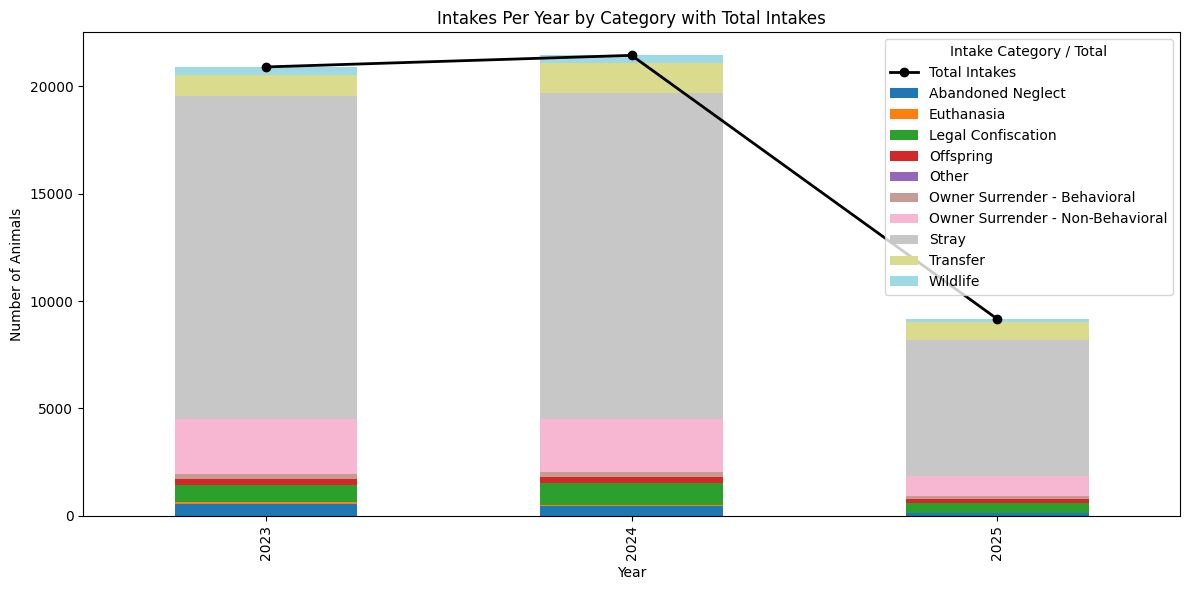

<Figure size 640x480 with 0 Axes>

In [128]:
# Copy dataframe
combined1 = combined.copy()

# Group by year and category
intakes_per_year = combined1.groupby([combined1['indate'].dt.year, 'intakeCategory']).size().unstack(fill_value=0)

# Total intakes per year
total_intakes = intakes_per_year.sum(axis=1)

# Plot stacked bars
fig, ax = plt.subplots(figsize=(12,6))
intakes_per_year.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

# Plot total intakes on the same x-axis
# numeric positions for bars
x = np.arange(len(total_intakes))  
ax.plot(x, total_intakes.values, color='black', marker='o', linewidth=2, label='Total Intakes')

# Fix x-ticks to show the year labels
ax.set_xticks(x)
ax.set_xticklabels(intakes_per_year.index)

plt.title("Intakes Per Year by Category with Total Intakes")
plt.xlabel("Year")
plt.ylabel("Number of Animals")
plt.legend(title="Intake Category / Total")
plt.tight_layout()
plt.show()

plt.savefig("../plots/IntakeYearandCategory.png")

Heatmap of Species Outcomes by Type

I wanted to see the outcome number for all species and be able to easily identify the most common at a glance.

I chose a Heatmap because it makes it easy to spot patterns and outliers in the data.

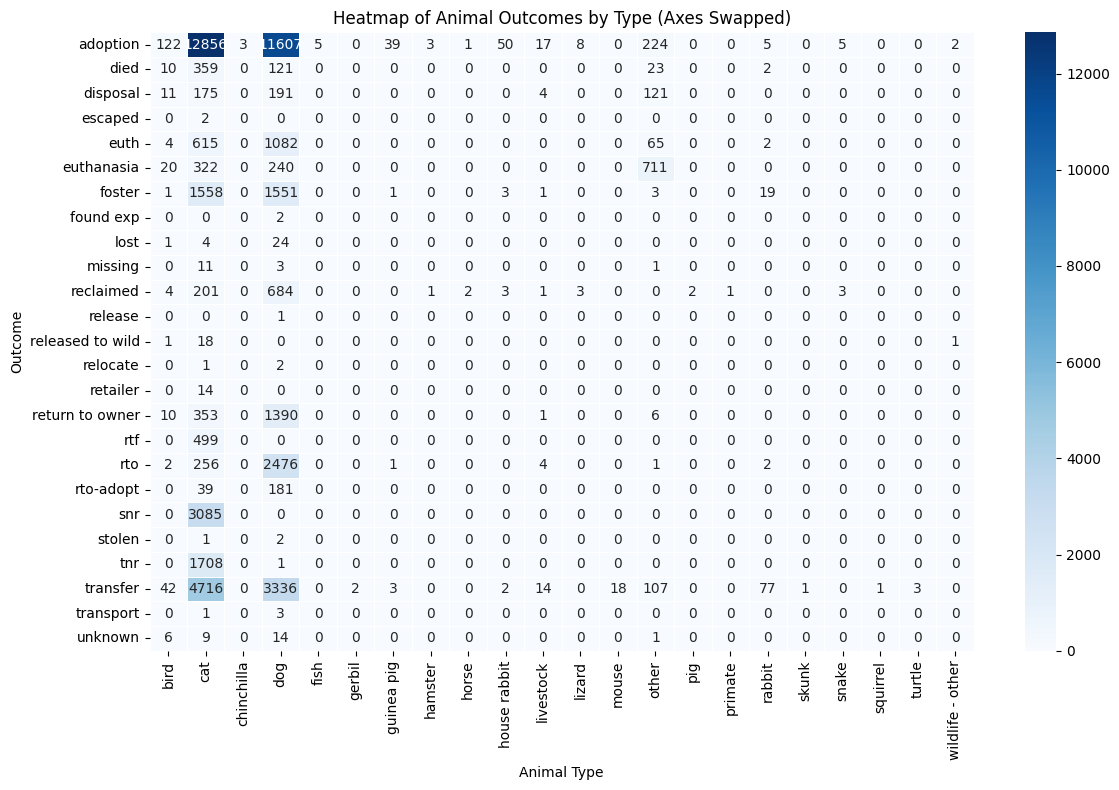

<Figure size 640x480 with 0 Axes>

In [129]:
# normalize the data before creating a pivot table
combined1['outcome'] = combined1['outcome'].str.lower().str.strip()
combined1['species'] = combined1['species'].str.lower().str.strip()


# Create pivot table: rows = outcomes, columns = animal types
heatmap_table = combined1.pivot_table(index='outcome', columns='species', aggfunc='size', fill_value=0)

# Plot the heatmap
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_table,
            annot=True,        # show numbers on each cell
            fmt="d",           # display numbers as integers
            cmap="Blues",      # color scheme
            linewidths=0.5,
            cbar=True)

# Add title and labels
plt.title("Heatmap of Animal Outcomes by Type (Axes Swapped)")
plt.xlabel("Animal Type")
plt.ylabel("Outcome")

plt.tight_layout()
plt.show()

plt.savefig("../plots/outcomeheatmap.png")

Positive vs Negative Outcome Types Ratio

I wanted to see averaged outcomes positive vs negative overall.
I needed to group the list of outcomes by what I considered positive, negative or unknown.

My grouping

- Positive includes: Adoption; Return to Owner, Foster, Transfer, Reunited
- Negative includes: Died, Euthanized
- Unknown includes: TNR, Wild Release, Unknown, Escaped, Lost, Stolen           
 
The positive is based on the animal being in a permanent home, foster home or being transported to a rescue where it would not be killed.

A negative is based on the outcome resulting in death of the animal.

Unknown is based on an outcome that could not be determined after the animal left the shelter.

I chose a Pie chart because it is best for showing simple comparisons among a small number of categories.

It highlights the largest and smallest categories very easily.

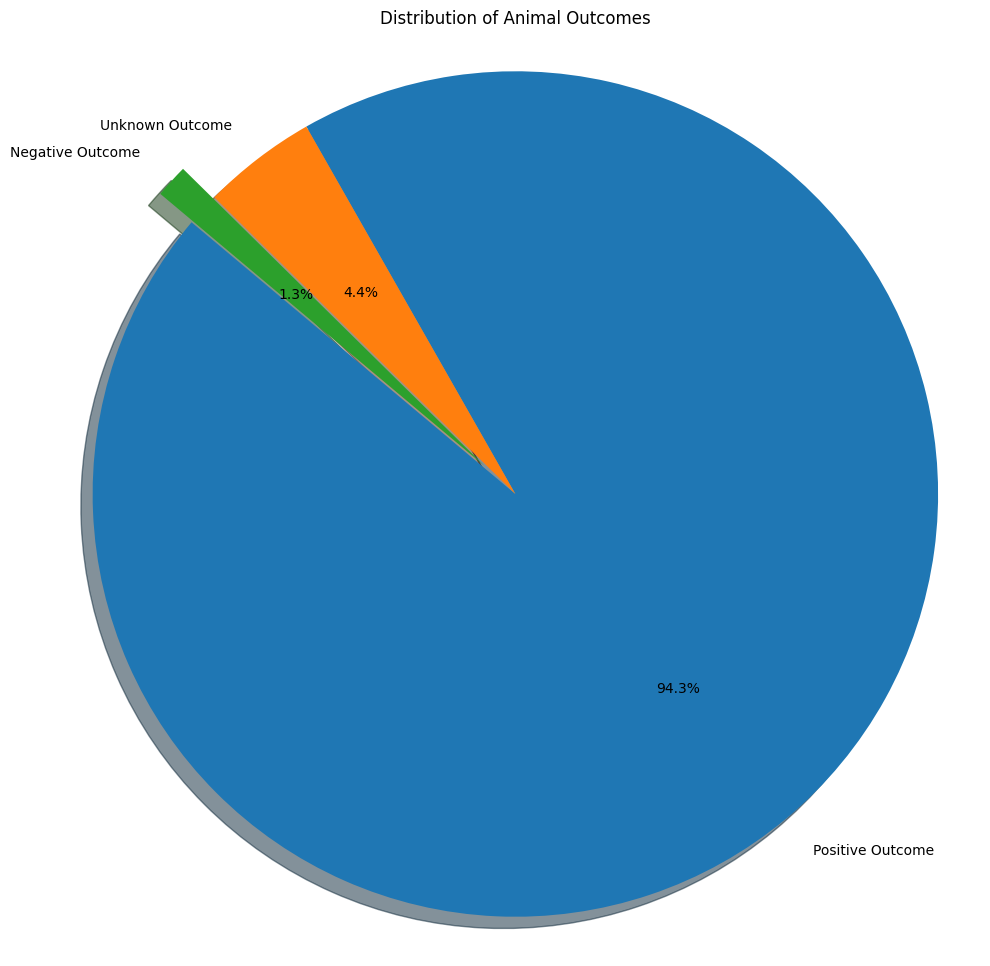

<Figure size 640x480 with 0 Axes>

In [130]:
# normalize the data before creating a pivot table
combined1['outcome'] = combined1['outcome'].str.lower().str.strip()

# Count positive outcomes which is a grouping of several outtake reasons per month
adoptions_df = combined1[combined1['outcome'].isin(['adoption', 'return to owner', 'foster', 'transfer', 'reunited'])]    
adoptions_per_month = adoptions_df.groupby(adoptions_df['outdate'].dt.to_period("M")).size().reset_index(name="count")
adoptions_per_month['outdate'] = adoptions_per_month['outdate'].dt.to_timestamp()

# Count spay/neuter and release and transfer to KHS per month
unknown_df = combined1[combined1['outcome'].isin(['tnr', 'wild release', 'unknown', 'escaped', 'lost', 'stolen'])]  
unknown_per_month = unknown_df.groupby(unknown_df['outdate'].dt.to_period("M")).size().reset_index(name="count")
unknown_per_month['outdate'] = unknown_per_month['outdate'].dt.to_timestamp()

# Count negative outcome per month
euth_df = combined1[combined1['outcome'].isin(['died', 'euthanized'])]  
euth_per_month = euth_df.groupby(euth_df['outdate'].dt.to_period("M")).size().reset_index(name="count")
euth_per_month['outdate'] = euth_per_month['outdate'].dt.to_timestamp()


# Total counts for each category
positive_count = adoptions_df.shape[0]   # All adoption-type outcomes
unknown_count = unknown_df.shape[0]      # All TNR/SNR/TRANSFER
negative_count = euth_df.shape[0]        # All EUTH/DIED/DISPOSAL

# Labels and values
labels = ['Positive Outcome', 'Unknown Outcome', 'Negative Outcome']
counts = [positive_count, unknown_count, negative_count]

# Optional: explode negative slice to emphasize it
explode = [0, 0, 0.1]  # only explode the negative outcomes

# Plot pie chart
plt.figure(figsize=(12,12))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, explode=explode, shadow=True)
plt.title("Distribution of Animal Outcomes")
plt.axis('equal')  # Equal aspect ratio makes it circular
plt.show()


plt.savefig("../plots/outcomeposnegpie.png")

Average Days in Shelter by Species

I wanted to easily see the average length of stay in the shelter for each species.

I chose a bar chart because it shows the length of stay without having to read thru a table of data.  Also,the differences in height of bars are immediately obvious and small differences between species are easy to spot visually.

In [131]:
# create a new dataframe
df_shelter = combined.copy()

# Subtract intake date from outcome date to get a timedelta, then convert to days
df_shelter['days_in_shelter'] = (df_shelter['outdate'] - df_shelter['indate']).dt.days

# Preview the new column
print(df_shelter[['species', 'indate', 'outdate', 'days_in_shelter']].head())

# Filter out any negative or missing days (if intake/outcome dates are missing)
df_shelter = df_shelter[df_shelter['days_in_shelter'] >= 0]

# Calculate the average days in shelter for each animal type
avg_days = df_shelter.groupby('species')['days_in_shelter'].mean().reset_index()

# Round the averages to the nearest integer
avg_days['days_in_shelter'] = avg_days['days_in_shelter'].round().astype(int)

print(avg_days)

print(avg_days)

  species     indate    outdate  days_in_shelter
0     dog 2024-02-05 2024-02-05                0
1     dog 2024-01-04 2024-03-05               61
2     cat 2024-07-27 2024-08-09               13
3     dog 2025-04-24 2025-04-26                2
4     cat 2024-09-24 2024-10-06               12
             species  days_in_shelter
0               bird               11
1                cat               19
2         chinchilla               10
3                dog               24
4               fish                5
5             gerbil               14
6         guinea pig               33
7            hamster                8
8              horse               36
9       house rabbit               70
10         livestock               60
11            lizard               47
12             mouse                2
13             other                8
14               pig                4
15           primate               28
16            rabbit                8
17             skunk  

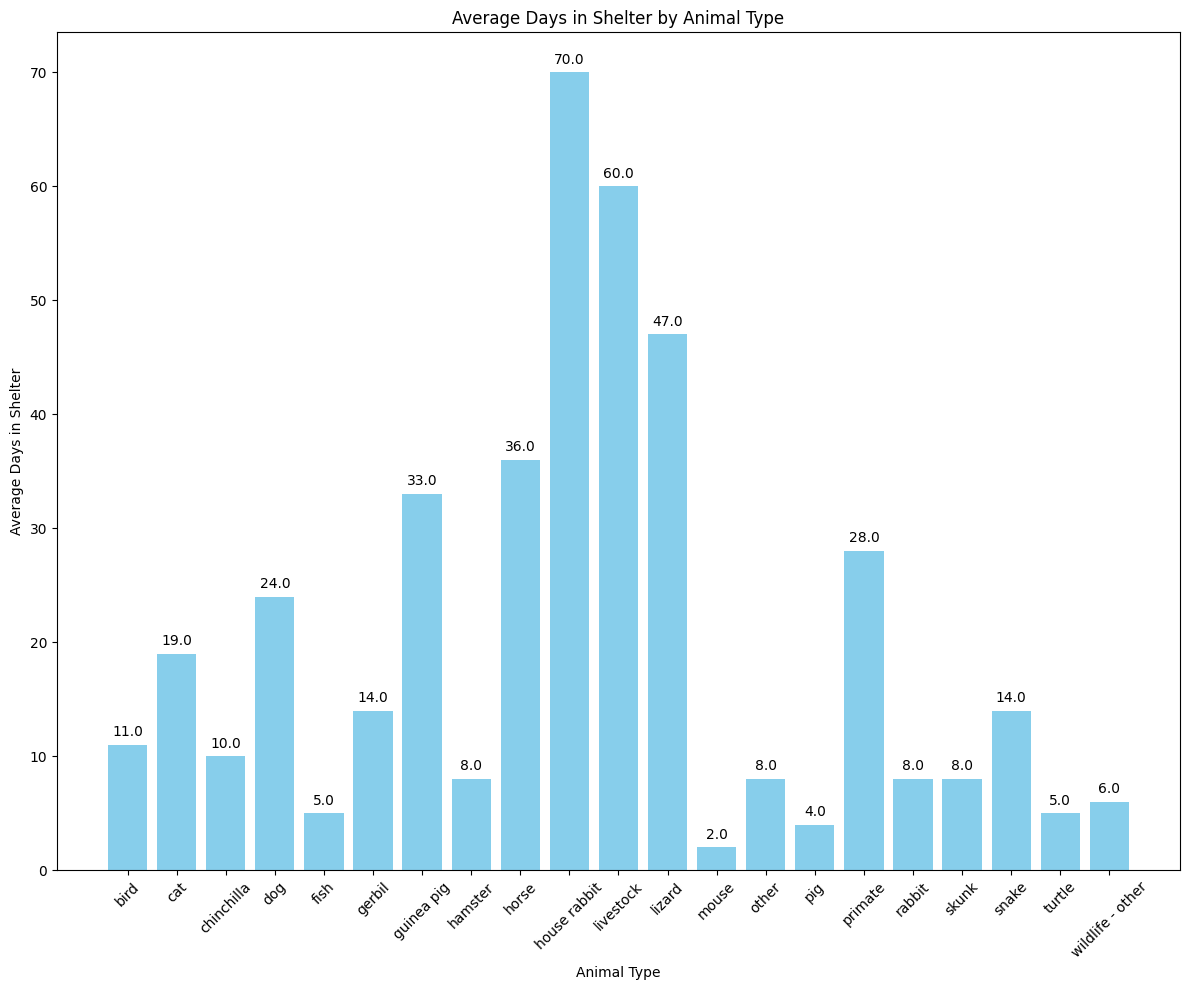

<Figure size 640x480 with 0 Axes>

In [132]:
plt.figure(figsize=(12,10))
bars = plt.bar(avg_days['species'], avg_days['days_in_shelter'], color='skyblue')

# Add title and labels
plt.title("Average Days in Shelter by Animal Type")
plt.xlabel("Animal Type")
plt.ylabel("Average Days in Shelter")

# Add exact numbers on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.1f}", ha='center', va='bottom')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.savefig("../plots/avgdaysinshelter.png")

Adoptions by Day of the Week

I wanted to show what days of the week adoptions were the highest. This would be useful when coordinating volunteers and having events to showcase the animals.

Additionally, this shows the days that might benefit from new ideas and efforts to get more traction to the shelter.

I chose a bar chart because it is best for comparing days of the week stay side-by-side.  It is very easy to see totals and how they rank with one another.

In [133]:
# create a new dataframe
adoptions_df = combined.copy()
# normalize the data before creating a pivot table
adoptions_df['outcome'] = adoptions_df['outcome'].str.lower().str.strip()

# Filter only adoption outcomes
adoptions = adoptions_df[adoptions_df['outcome'] == "adoption"]

# Create a new column for the day of the week 
adoptions['day_of_week'] = adoptions['outdate'].dt.day_name()

# Count adoptions by day
adoptions_by_day = adoptions['day_of_week'].value_counts()

# Make sure days are in correct order
days_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
adoptions_by_day = adoptions_by_day.reindex(days_order)

# DataFrame version to see it tabular
adoptions_by_day_data = adoptions['day_of_week'].value_counts().reindex(
    days_order
).reset_index()

adoptions_by_day_data.columns = ['day_of_week', 'count']

print(adoptions_by_day_data)

  day_of_week  count
0      Monday   3178
1     Tuesday   4032
2   Wednesday   2960
3    Thursday   3740
4      Friday   4285
5    Saturday   4191
6      Sunday   2561


/var/folders/6j/ng0s8_v10mj7kwbwccbbwd840000gn/T/ipykernel_85767/429379179.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adoptions['day_of_week'] = adoptions['outdate'].dt.day_name()


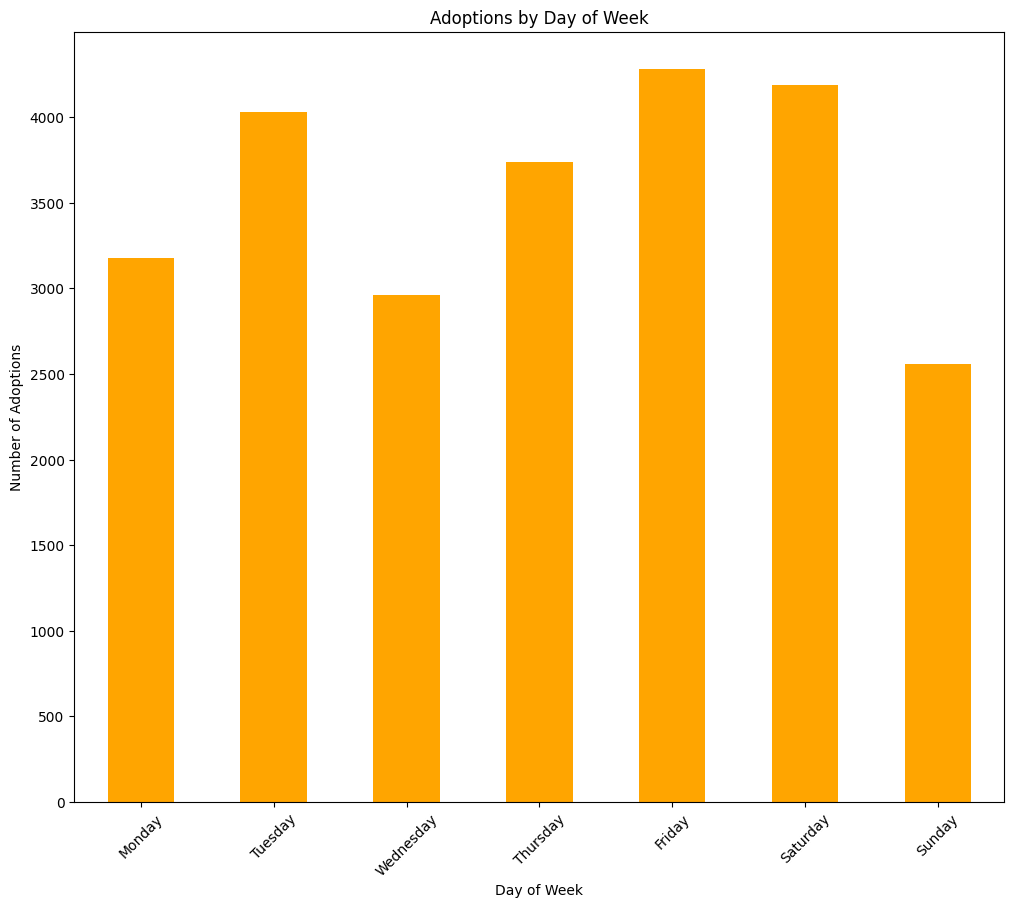

<Figure size 640x480 with 0 Axes>

In [134]:
# Plot
plt.figure(figsize=(12,10))
adoptions_by_day.plot(kind='bar', color='orange')
plt.title("Adoptions by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Adoptions")
plt.xticks(rotation=45)
plt.show()

plt.savefig("../plots/adoptionsbydayofweek.png")